# ⚙️ 02 — Data Preprocessing
### World Development Clustering Pipeline

---

**Purpose:** Execute and visualise every preprocessing step — the exact same logic as `data_ingestion.py` + `data_preprocessing.py`.  
**Pipeline stages:** Stage 1 (ingestion) + Stage 2 (preprocessing)  
**Input:**  `data/raw/World_development_mesurement.xlsx`  
**Output:** `data/processed/cleaned_data.csv` → `data/processed/scaled_data.csv`

---

### 🔧 Preprocessing Order (Mandatory)
| Step | Operation | File | Why |
|------|-----------|------|-----|
| 1 | Load raw Excel, parse types | `data_ingestion.py` | Foundation |
| 2 | Assign Year (2000–2012) | `data_ingestion.py` | Required for trend computation |
| 3 | Compute OLS trend slopes (BEFORE agg) | `data_ingestion.py` | Fix 1: preserves trajectory info |
| 4 | Aggregate panel → country means | `data_ingestion.py` | Panel → cross-sectional |
| 5 | Merge trend features | `data_ingestion.py` | Re-attach trend slopes |
| 6 | Standardize country names | `data_ingestion.py` | Fix 9: choropleth compatibility |
| 7 | Drop cols >40% missing | `data_preprocessing.py` | Reduces dimensionality first |
| 8 | Drop rows >50% missing | `data_preprocessing.py` | Before imputation |
| 9 | IQR × 3.0 outlier capping | `data_preprocessing.py` | Bounds before median estimates |
| 10 | SimpleImputer(median) | `data_preprocessing.py` | Robust, no distance computation |
| 11 | log1p transform (GDP, Tourism) | `data_preprocessing.py` | Normalize skewed distributions |
| 12 | StandardScaler | `data_preprocessing.py` | Zero mean, unit variance |

---
## 1. Environment Setup

In [1]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy import stats
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from IPython.display import display

from config.config import (
    RAW_FILE, SHEET_NAME, ID_COL,
    CURRENCY_COLS, PERCENT_COLS, DROP_COLS,
    TREND_COLS, COUNTRY_NAME_MAP,
    CLEANED_DATA, SCALED_DATA,
    HIGH_MISSING_COL_THRESHOLD, HIGH_MISSING_ROW_THRESHOLD,
    IQR_CAP_MULTIPLIER, LOG1P_COLS,
    IMPUTER_PATH, SCALER_PATH, PROCESSED_DIR,
)
from src.utils.helpers import strip_currency, strip_percent, get_numeric_feature_cols

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120})
PALETTE = sns.color_palette('tab10')

print('✅ Environment ready')

✅ Environment ready


---
## Stage 1 — Data Ingestion
### Step 1–2: Load Raw Data & Parse Types

In [2]:
# ── Load raw Excel ────────────────────────────────────────────────────────────
df = pd.read_excel(RAW_FILE, sheet_name=SHEET_NAME)
print(f'Raw shape: {df.shape}  |  Countries: {df[ID_COL].nunique()}')

# ── Parse currency and percent strings ───────────────────────────────────────
for col in CURRENCY_COLS:
    if col in df.columns and not pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].apply(strip_currency)

for col in PERCENT_COLS:
    if col in df.columns and not pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].apply(strip_percent)

# ── Drop unusable columns ─────────────────────────────────────────────────────
cols_dropped_early = [c for c in DROP_COLS if c in df.columns]
df = df.drop(columns=cols_dropped_early)
print(f'Dropped unusable columns: {cols_dropped_early}')
print(f'After type fix & drop: {df.shape}')

Raw shape: (2704, 25)  |  Countries: 208
Dropped unusable columns: ['Ease of Business', 'Number of Records']
After type fix & drop: (2704, 23)


### Step 3: Compute Trend Features BEFORE Aggregation

> **Fix 1** — Critical design decision: OLS slope per country per indicator is computed **before** aggregation.  
> After mean aggregation, all temporal information is lost. Two countries with identical means but  
> opposite trajectories (one growing, one declining) look identical to the clusterer.

In [3]:
# ── Assign Year (2000–2012) based on cumulative row count per country ─────────
df['Year'] = df.groupby(ID_COL).cumcount() + 2000

# ── OLS trend slope computation ───────────────────────────────────────────────
trend_records = []
for country, grp in df.groupby(ID_COL):
    row   = {ID_COL: country}
    years = grp['Year'].values.astype(float)
    for col in TREND_COLS:
        if col not in grp.columns:
            row[f'{col}_trend'] = np.nan
            continue
        vals = grp[col].values.astype(float)
        mask = ~np.isnan(vals)
        if mask.sum() >= 3:
            slope, *_ = stats.linregress(years[mask], vals[mask])
            row[f'{col}_trend'] = round(float(slope), 6)
        else:
            row[f'{col}_trend'] = np.nan
    trend_records.append(row)

df_trends = pd.DataFrame(trend_records)
trend_feat_cols = [c for c in df_trends.columns if c != ID_COL]

print(f'Trend features computed: {len(trend_feat_cols)}')
trend_null_counts = {c: int(df_trends[c].isnull().sum()) for c in trend_feat_cols if df_trends[c].isnull().any()}
if trend_null_counts:
    print(f'Trend nulls (to be imputed later): {trend_null_counts}')
display(df_trends.head(4))

Trend features computed: 5
Trend nulls (to be imputed later): {'GDP_trend': 13, 'Internet Usage_trend': 9, 'CO2 Emissions_trend': 13, 'Life Expectancy Female_trend': 9, 'Mobile Phone Usage_trend': 6}


,Country,GDP_trend,Internet Usage_trend,CO2 Emissions_trend,Life Expectancy Female_trend,Mobile Phone Usage_trend
0,Afghanistan,1.581051e+09,0.006993,681.054545,0.500000,0.076364
1,Albania,8.691805e+08,0.050549,84.454545,0.230769,0.085714
2,Algeria,1.344966e+10,0.014286,4220.627273,0.148352,0.102198
3,American Samoa,NaN,NaN,NaN,NaN,0.000000


### Steps 4–6: Aggregate, Merge Trends, Standardize Country Names

In [4]:
# ── Aggregate panel to cross-sectional (mean per country) ────────────────────
df_agg = df.groupby(ID_COL).mean(numeric_only=True).reset_index()
if 'Year' in df_agg.columns:
    df_agg = df_agg.drop(columns=['Year'])
print(f'After aggregation: {df_agg.shape}  (208 countries × features)')

# ── Merge trend features ──────────────────────────────────────────────────────
df_cleaned = df_agg.merge(df_trends, on=ID_COL, how='left')
print(f'After merging trends: {df_cleaned.shape}')

# ── Standardize country names (Fix 9) ────────────────────────────────────────
renamed = 0
for original, standardized in COUNTRY_NAME_MAP.items():
    mask = df_cleaned[ID_COL] == original
    if mask.any():
        df_cleaned.loc[mask, ID_COL] = standardized
        renamed += 1
print(f'Country names standardized: {renamed} renamed for Plotly choropleth compatibility')

# ── Save cleaned data ─────────────────────────────────────────────────────────
os.makedirs(PROCESSED_DIR, exist_ok=True)
df_cleaned.to_csv(CLEANED_DATA, index=False)
print(f'\n✅ cleaned_data.csv saved | shape: {df_cleaned.shape}')

After aggregation: (208, 23)  (208 countries × features)
After merging trends: (208, 28)
Country names standardized: 30 renamed for Plotly choropleth compatibility

✅ cleaned_data.csv saved | shape: (208, 28)


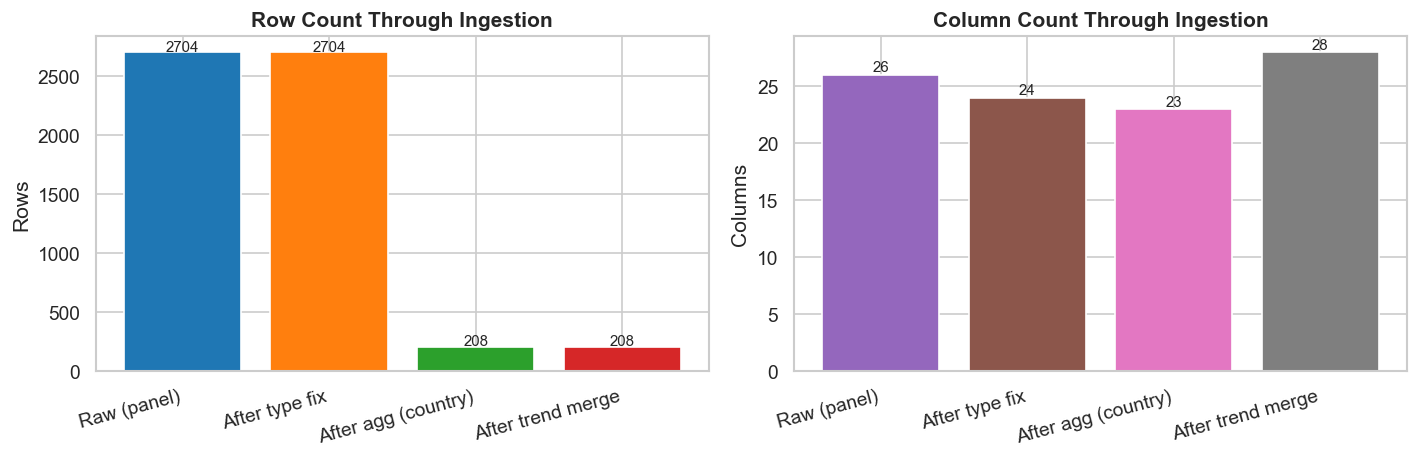

In [5]:
# ── Visual: shape change through ingestion stages ─────────────────────────────
stages = ['Raw (panel)', 'After type fix', 'After agg (country)', 'After trend merge']
shapes = [
    (2704, df.shape[1] + len(cols_dropped_early)),
    (df.shape[0], df.shape[1]),
    (df_agg.shape[0], df_agg.shape[1]),
    (df_cleaned.shape[0], df_cleaned.shape[1]),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
rows = [s[0] for s in shapes]
cols = [s[1] for s in shapes]

axes[0].bar(stages, rows, color=PALETTE[:4])
axes[0].set_title('Row Count Through Ingestion', fontweight='bold')
axes[0].set_ylabel('Rows')
for i, v in enumerate(rows):
    axes[0].text(i, v + 10, str(v), ha='center', fontsize=9)

axes[1].bar(stages, cols, color=PALETTE[4:8])
axes[1].set_title('Column Count Through Ingestion', fontweight='bold')
axes[1].set_ylabel('Columns')
for i, v in enumerate(cols):
    axes[1].text(i, v + 0.3, str(v), ha='center', fontsize=9)

for ax in axes:
    ax.set_xticklabels(stages, rotation=15, ha='right')
plt.tight_layout()
plt.show()

---
## Stage 2 — Data Preprocessing
### Step 7: Drop High-Missing Columns (>40%)

In [6]:
df_pp = pd.read_csv(CLEANED_DATA)  # fresh load (as preprocessing.py does)

feature_cols  = get_numeric_feature_cols(df_pp)
missing_fracs = df_pp[feature_cols].isnull().mean()
high_miss_cols = missing_fracs[missing_fracs > HIGH_MISSING_COL_THRESHOLD].index.tolist()

print(f'Columns > {HIGH_MISSING_COL_THRESHOLD*100:.0f}% missing:')
for c in high_miss_cols:
    print(f'  DROP  {c:<35}  ({missing_fracs[c]*100:.1f}%)')

if high_miss_cols:
    df_pp = df_pp.drop(columns=high_miss_cols)

print(f'\nShape after column drop: {df_pp.shape}')

Columns > 40% missing:

Shape after column drop: (208, 28)


### Step 8: Drop High-Missing Rows (>50%)

> Rows (countries) with >50% missing features cannot be reliably imputed.  
> Must be dropped **before** imputation so median estimates are not skewed.

Rows dropped (>50% missing): 10
Countries removed: ['American Samoa', 'Cayman Islands', 'Curacao', 'Guam', 'Isle of Man', 'Liechtenstein', 'Monaco', 'Sint Maarten', 'Saint Martin', 'Turks and Caicos Islands']
Shape after row drop: (198, 28)


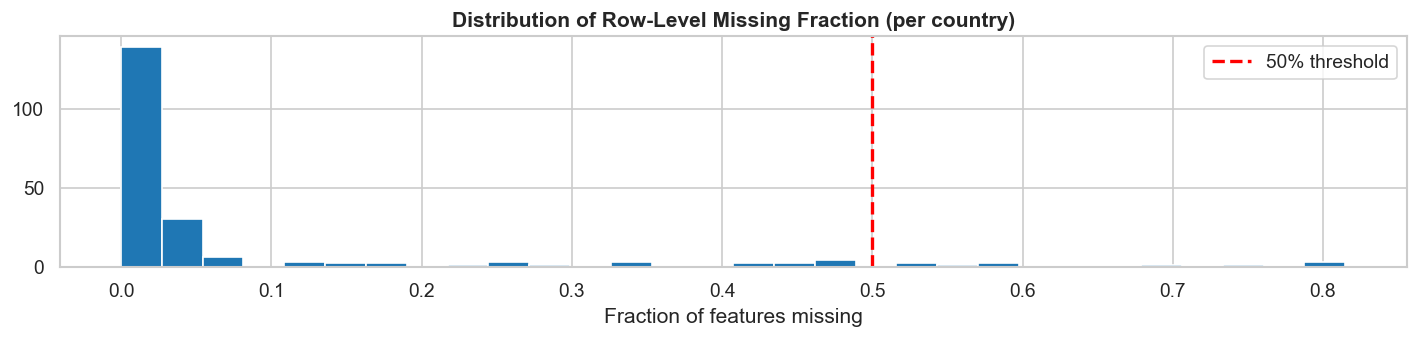

In [7]:
feat_cols_now     = get_numeric_feature_cols(df_pp)
row_missing_fracs = df_pp[feat_cols_now].isnull().mean(axis=1)
drop_mask         = row_missing_fracs > HIGH_MISSING_ROW_THRESHOLD

dropped_countries = df_pp.loc[drop_mask, ID_COL].tolist() if ID_COL in df_pp.columns else []
print(f'Rows dropped (>{HIGH_MISSING_ROW_THRESHOLD*100:.0f}% missing): {int(drop_mask.sum())}')
if dropped_countries:
    print(f'Countries removed: {dropped_countries}')

df_pp = df_pp[~drop_mask].reset_index(drop=True)
print(f'Shape after row drop: {df_pp.shape}')

# ── Plot row-level missing fractions ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 3))
ax.hist(row_missing_fracs, bins=30, color='#1f77b4', edgecolor='white')
ax.axvline(HIGH_MISSING_ROW_THRESHOLD, color='red', linestyle='--', lw=2,
           label=f'{HIGH_MISSING_ROW_THRESHOLD*100:.0f}% threshold')
ax.set_title('Distribution of Row-Level Missing Fraction (per country)', fontweight='bold')
ax.set_xlabel('Fraction of features missing')
ax.legend()
plt.tight_layout()
plt.show()

### Step 9: IQR × 3.0 Outlier Capping

In [8]:
feat_cols = get_numeric_feature_cols(df_pp)
df_before_cap = df_pp.copy()
capping_log = []

for col in feat_cols:
    series = df_pp[col].dropna()
    if len(series) == 0:
        continue
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        continue
    lo, hi = q1 - IQR_CAP_MULTIPLIER * iqr, q3 + IQR_CAP_MULTIPLIER * iqr
    n_cap = int((df_pp[col] < lo).sum()) + int((df_pp[col] > hi).sum())
    if n_cap > 0:
        df_pp[col] = df_pp[col].clip(lower=lo, upper=hi)
        capping_log.append({'feature': col, 'n_capped': n_cap, 'lower': round(lo, 3), 'upper': round(hi, 3)})

cap_df = pd.DataFrame(capping_log).sort_values('n_capped', ascending=False)
print(f'Total features with capped values: {len(capping_log)}')
print(f'Total capped cells: {cap_df["n_capped"].sum()}')
display(cap_df.head(10))

Total features with capped values: 15
Total capped cells: 211


,feature,n_capped,lower,upper
13,CO2 Emissions_trend,35,-1.999227e+03,2.671936e+03
1,CO2 Emissions,23,-1.745571e+05,2.362443e+05
6,Health Exp/Capita,22,-1.604192e+03,2.260885e+03
3,Energy Usage,19,-8.345394e+04,1.167685e+05
11,Tourism Outbound,19,-8.173269e+09,1.114951e+10
4,GDP,17,-3.364379e+11,4.577647e+11
12,GDP_trend,16,-3.761427e+10,5.107828e+10
10,Tourism Inbound,15,-1.023760e+10,1.399277e+10
9,Population Total,14,-5.731260e+07,7.975162e+07
14,Life Expectancy Female_trend,8,-3.460000e-01,8.850000e-01


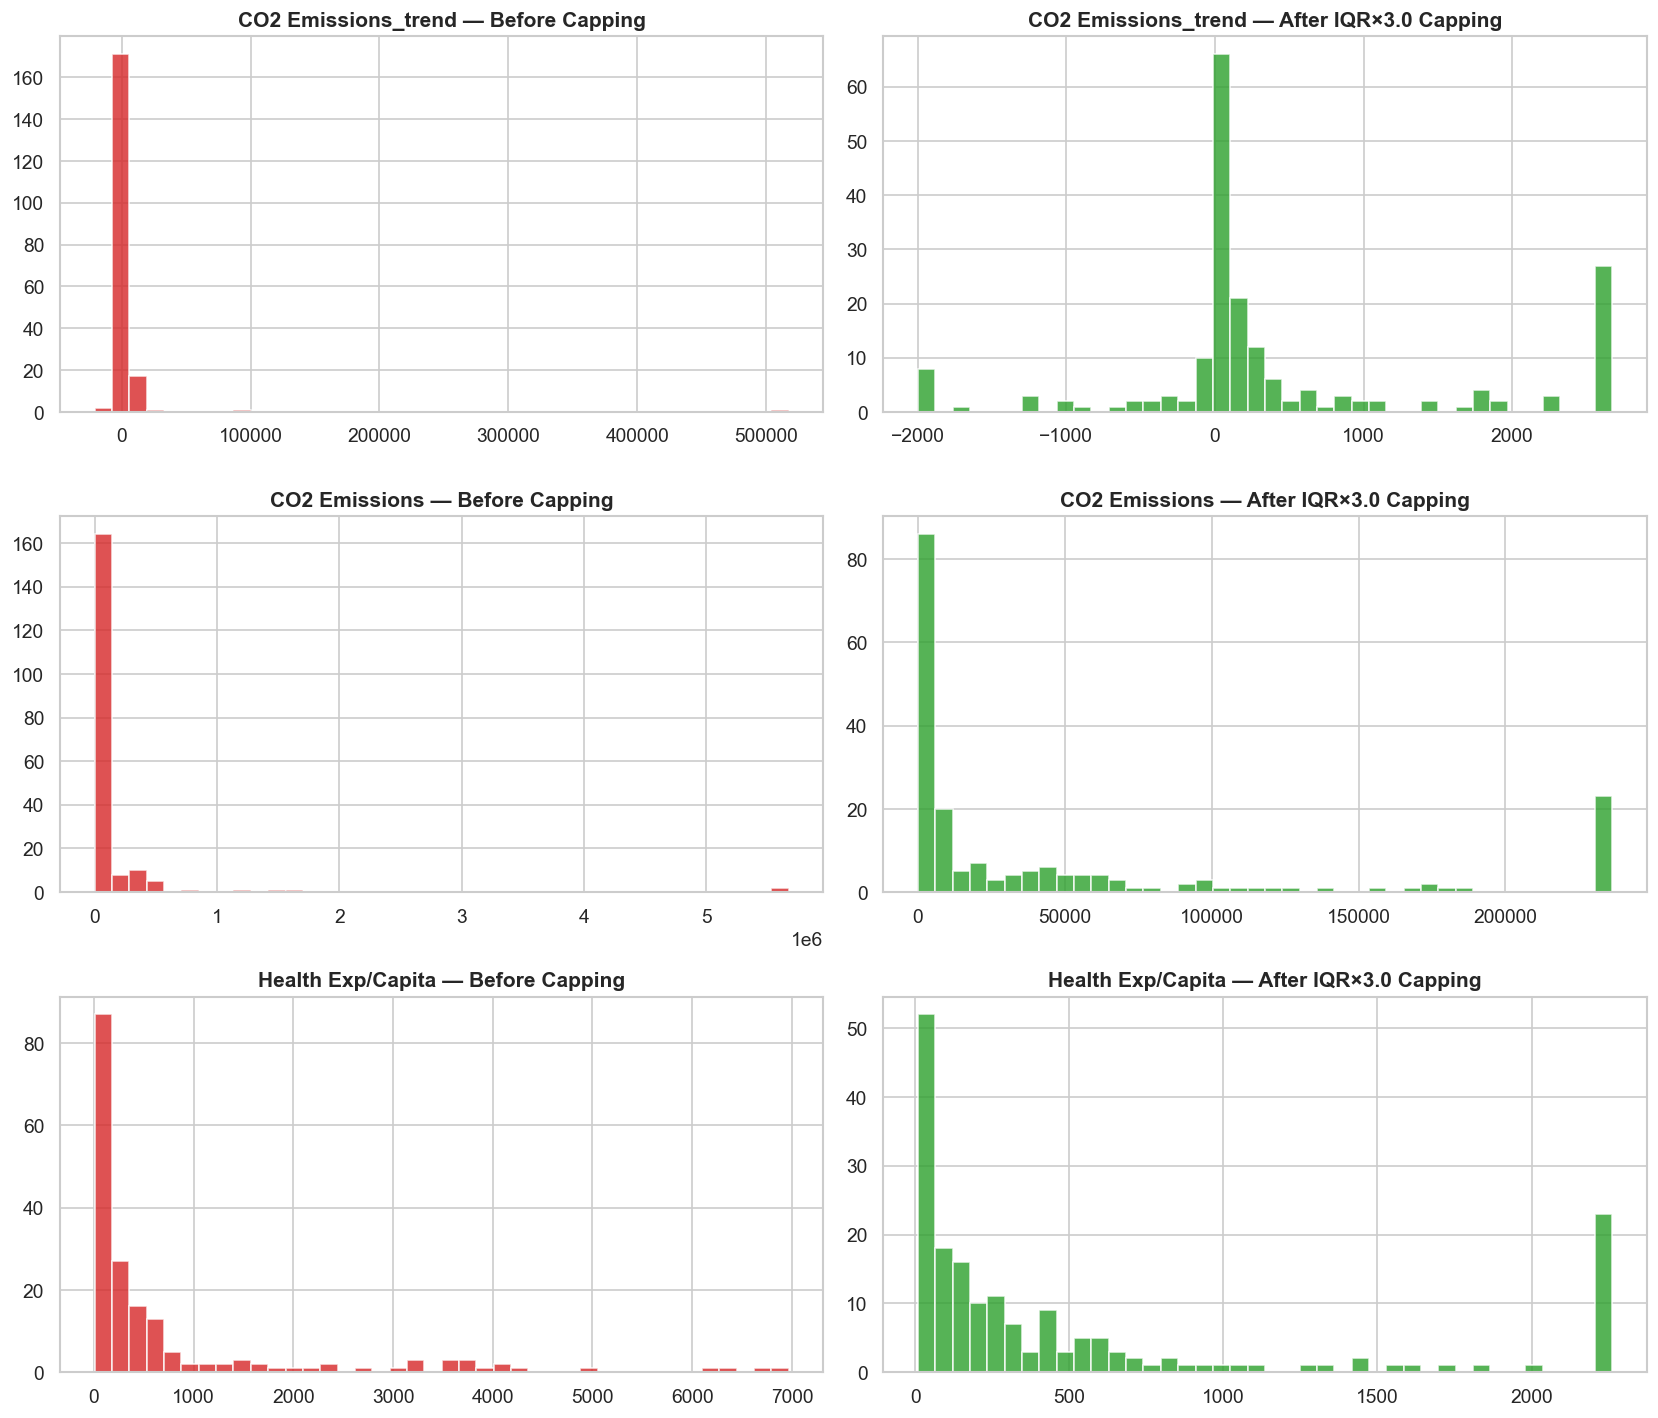

In [9]:
# ── Before vs after capping for top 3 features ───────────────────────────────
top_cap_cols = cap_df.head(3)['feature'].tolist()
if top_cap_cols:
    fig, axes = plt.subplots(len(top_cap_cols), 2, figsize=(14, 4 * len(top_cap_cols)))
    if len(top_cap_cols) == 1:
        axes = [axes]
    for i, col in enumerate(top_cap_cols):
        before = df_before_cap[col].dropna()
        after  = df_pp[col].dropna()
        axes[i][0].hist(before, bins=40, color='#d62728', edgecolor='white', alpha=0.8)
        axes[i][0].set_title(f'{col} — Before Capping', fontweight='bold')
        axes[i][1].hist(after,  bins=40, color='#2ca02c', edgecolor='white', alpha=0.8)
        axes[i][1].set_title(f'{col} — After IQR×{IQR_CAP_MULTIPLIER} Capping', fontweight='bold')
    plt.tight_layout()
    plt.show()

### Step 10: SimpleImputer (Median)

> **Why SimpleImputer(median) not KNNImputer:**  
> - Robust to outliers (median, not mean)  
> - No pairwise distance computation — safe for sparse data  
> - Consistent and reproducible every run

In [10]:
feat_cols = get_numeric_feature_cols(df_pp)
n_before  = int(df_pp[feat_cols].isnull().sum().sum())

imputer = SimpleImputer(strategy='median')
df_pp[feat_cols] = imputer.fit_transform(df_pp[feat_cols])

n_after = int(df_pp[feat_cols].isnull().sum().sum())

os.makedirs(PROCESSED_DIR, exist_ok=True)
joblib.dump(imputer, IMPUTER_PATH)

print(f'Missing values: {n_before} → {n_after}')
print(f'Imputer saved to: {IMPUTER_PATH}')

# ── Visualize imputed values distribution check ───────────────────────────────
# Check that imputed medians look reasonable vs original distributions
print('\nImputer feature medians (top 5):')
medians = dict(zip(feat_cols, imputer.statistics_[:5]))
for k, v in medians.items():
    print(f'  {k:<35}: {v:.4f}')

Missing values: 229 → 0
Imputer saved to: c:\Users\graj2\Data Science\Projects\World-Development-Clustering\data\processed\imputer.pkl

Imputer feature medians (top 5):
  Birth Rate                         : 0.0208
  Business Tax Rate                  : 41.0625
  CO2 Emissions                      : 9190.0909
  Days to Start Business             : 27.7000
  Energy Usage                       : 8974.1667


### Step 11: log1p Transform

log1p Transform Effect on Skewness:


,column,skew_before,skew_after,improvement
0,GDP,1.680,-0.142,1.538
1,Tourism Inbound,1.703,-0.416,1.287
2,Tourism Outbound,1.752,-0.313,1.440


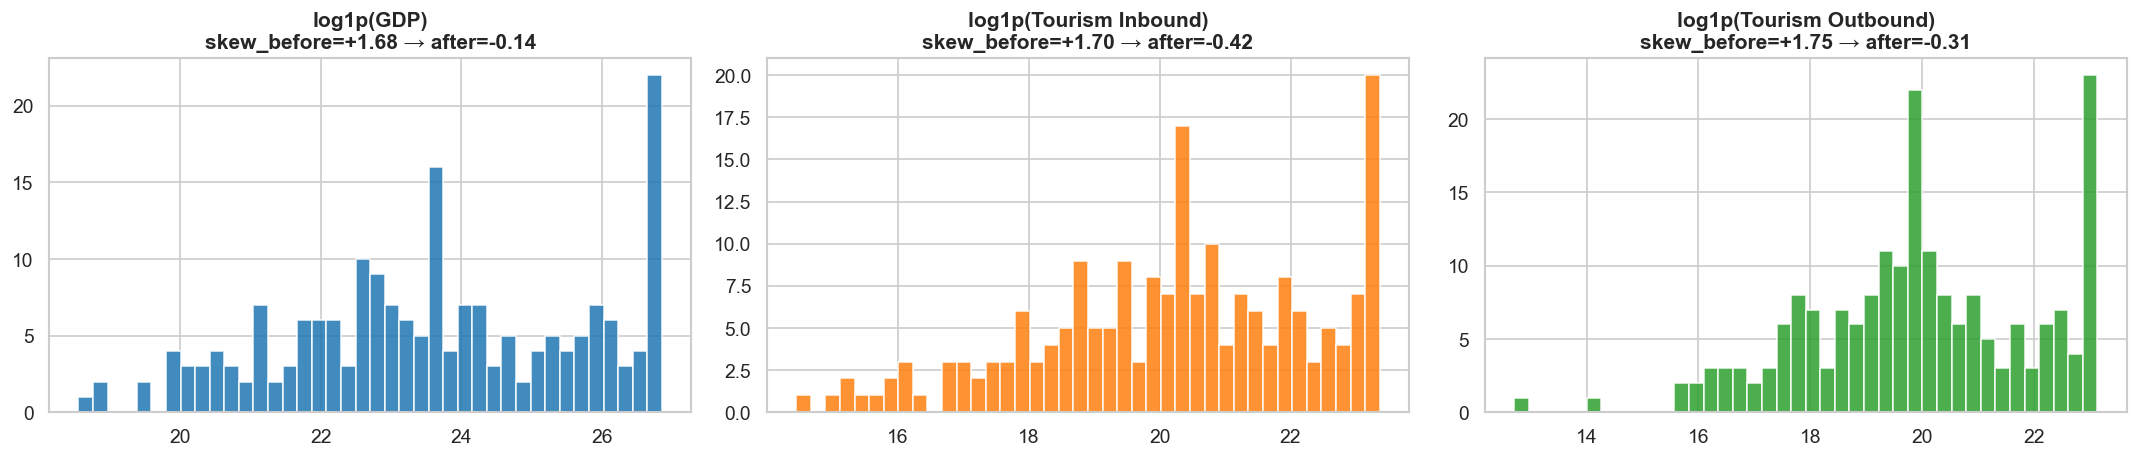

In [11]:
transform_results = []
for col in LOG1P_COLS:
    if col in df_pp.columns:
        skew_before = df_pp[col].skew()
        df_pp[col]  = np.log1p(df_pp[col].clip(lower=0))
        skew_after  = df_pp[col].skew()
        transform_results.append({'column': col, 'skew_before': round(skew_before, 3),
                                   'skew_after': round(skew_after, 3),
                                   'improvement': round(abs(skew_before) - abs(skew_after), 3)})

t_df = pd.DataFrame(transform_results)
print('log1p Transform Effect on Skewness:')
display(t_df)

# ── Side-by-side histograms ───────────────────────────────────────────────────
log_cols_present = [r['column'] for _, r in t_df.iterrows() if r['column'] in df_pp.columns]
if log_cols_present:
    fig, axes = plt.subplots(1, len(log_cols_present), figsize=(6 * len(log_cols_present), 4))
    if len(log_cols_present) == 1:
        axes = [axes]
    for i, col in enumerate(log_cols_present):
        row = t_df[t_df['column'] == col].iloc[0]
        axes[i].hist(df_pp[col].dropna(), bins=40, color=PALETTE[i], edgecolor='white', alpha=0.85)
        axes[i].set_title(f'log1p({col})\nskew_before={row.skew_before:+.2f} → after={row.skew_after:+.2f}',
                          fontweight='bold')
    plt.tight_layout()
    plt.show()

### Step 12: StandardScaler

In [12]:
feat_cols = get_numeric_feature_cols(df_pp)

scaler = StandardScaler()
df_pp[feat_cols] = scaler.fit_transform(df_pp[feat_cols])

joblib.dump(scaler, SCALER_PATH)

print(f'StandardScaler applied to {len(feat_cols)} features')
print(f'Scaler saved to: {SCALER_PATH}')
print(f'\nPost-scaling stats:')
scaled_stats = df_pp[feat_cols].describe().T[['mean', 'std']].round(4)
print(scaled_stats.head(8).to_string())

# ── Save scaled data ──────────────────────────────────────────────────────────
df_pp.to_csv(SCALED_DATA, index=False)
print(f'\n✅ scaled_data.csv saved | shape: {df_pp.shape}')

StandardScaler applied to 27 features
Scaler saved to: c:\Users\graj2\Data Science\Projects\World-Development-Clustering\data\processed\scaler.pkl

Post-scaling stats:
                        mean     std
Birth Rate               0.0  1.0025
Business Tax Rate        0.0  1.0025
CO2 Emissions           -0.0  1.0025
Days to Start Business   0.0  1.0025
Energy Usage            -0.0  1.0025
GDP                     -0.0  1.0025
Health Exp % GDP        -0.0  1.0025
Health Exp/Capita        0.0  1.0025

✅ scaled_data.csv saved | shape: (198, 28)


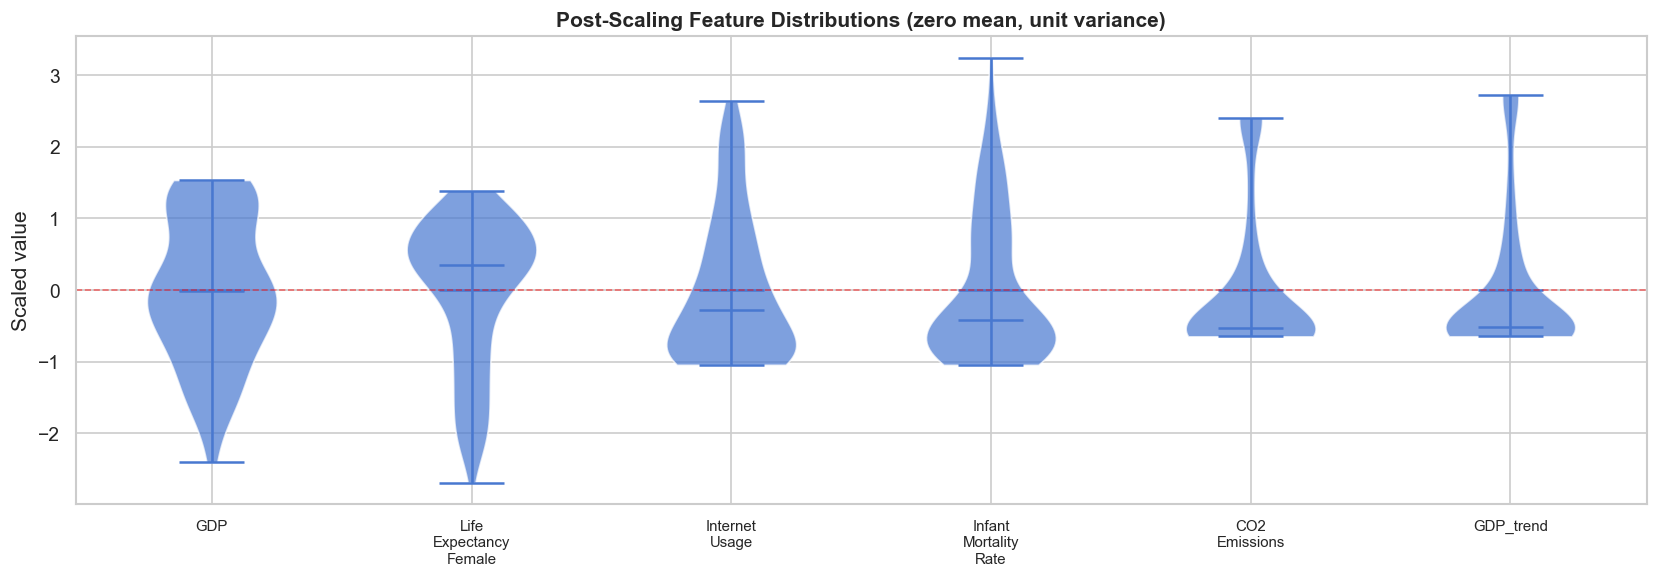

In [13]:
# ── Post-scaling distribution check: violin plots ────────────────────────────
sample_feat = [c for c in ['GDP', 'Life Expectancy Female', 'Internet Usage',
                             'Infant Mortality Rate', 'CO2 Emissions',
                             'GDP_trend', 'Internet Usage_trend'] if c in df_pp.columns][:6]

fig, ax = plt.subplots(figsize=(14, 5))
plot_data = [df_pp[c].values for c in sample_feat]
parts = ax.violinplot(plot_data, showmeans=True, showmedians=True)
for pc in parts['bodies']:
    pc.set_alpha(0.7)
ax.set_xticks(range(1, len(sample_feat) + 1))
ax.set_xticklabels([c.replace(' ', '\n') for c in sample_feat], fontsize=9)
ax.axhline(0, color='red', linestyle='--', lw=1, alpha=0.5)
ax.set_title('Post-Scaling Feature Distributions (zero mean, unit variance)', fontweight='bold')
ax.set_ylabel('Scaled value')
plt.tight_layout()
plt.show()

---
## 3. Preprocessing Summary

In [14]:
df_cleaned_check = pd.read_csv(CLEANED_DATA)
df_scaled_check  = pd.read_csv(SCALED_DATA)

summary = {
    'Stage'              : ['Raw (panel)', 'Cleaned (country-level)', 'Scaled (model-ready)'],
    'Rows'               : [2704, len(df_cleaned_check), len(df_scaled_check)],
    'Columns'            : [df.shape[1] + len(cols_dropped_early),
                            df_cleaned_check.shape[1],
                            df_scaled_check.shape[1]],
    'Null values'        : ['—', int(df_cleaned_check.isnull().sum().sum()),
                            int(df_scaled_check.isnull().sum().sum())],
    'Artifacts saved'    : ['—', 'cleaned_data.csv', 'scaled_data.csv + imputer.pkl + scaler.pkl'],
}

print('Preprocessing Pipeline Summary:')
display(pd.DataFrame(summary))
print('\n✅ Preprocessing complete — proceed to Notebook 03: Model Building')

Preprocessing Pipeline Summary:


,Stage,Rows,Columns,Null values,Artifacts saved
0,Raw (panel),2704,26,—,—
1,Cleaned (country-level),208,28,409,cleaned_data.csv
2,Scaled (model-ready),198,28,0,scaled_data.csv + imputer.pkl + scaler.pkl



✅ Preprocessing complete — proceed to Notebook 03: Model Building
